# Talep Tahmini (Demand Forecasting) Projesi

Bu proje, tarihsel satış verilerini kullanarak gelecekteki ürün talebini tahmin etmeyi amaçlamaktadır.

## İçerik
1. Veri Yükleme ve Keşif
2. Veri Ön İşleme
3. Özellik Mühendisliği
4. Model Eğitimi
5. Model Değerlendirme
6. Tahmin ve Sonuçlar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Veri Yükleme ve Keşif

In [2]:
df = pd.read_csv('../data/demand_forecasting.csv')

print('Veri Seti Boyutu:', df.shape)
print('\nSütunlar:', df.columns.tolist())
print('\nVeri Tipleri:')
print(df.dtypes)

Veri Seti Boyutu: (76000, 16)

Sütunlar: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']

Veri Tipleri:
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object


In [3]:
df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


In [4]:
print('\nİstatistiksel Özet:')
df.describe()


İstatistiksel Özet:


,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [5]:
print('\nEksik Değerler:')
print(df.isnull().sum())

print('\nBenzersiz Değerler:')
for col in df.columns:
    print(f'{col}: {df[col].nunique()}')


Eksik Değerler:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

Benzersiz Değerler:
Date: 760
Store ID: 5
Product ID: 20
Category: 5
Region: 4
Inventory Level: 1426
Units Sold: 330
Units Ordered: 996
Price: 15396
Discount: 6
Weather Condition: 4
Promotion: 2
Competitor Pricing: 15963
Seasonality: 4
Epidemic: 2
Demand: 340


## 2. Veri Ön İşleme

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

print('Tarih Aralığı:', df['Date'].min(), ' - ', df['Date'].max())
print('\nMağaza Sayısı:', df['Store ID'].nunique())
print('Ürün Sayısı:', df['Product ID'].nunique())
print('Kategori Sayısı:', df['Category'].nunique())

Tarih Aralığı: 2022-01-01 00:00:00  -  2024-01-30 00:00:00

Mağaza Sayısı: 5
Ürün Sayısı: 20
Kategori Sayısı: 5


In [7]:
print('Kategoriler:', df['Category'].unique())
print('\nBölgeler:', df['Region'].unique())
print('\nMevsimler:', df['Seasonality'].unique())
print('\nHava Durumları:', df['Weather Condition'].unique())

Kategoriler: ['Electronics' 'Clothing' 'Groceries' 'Toys' 'Furniture']

Bölgeler: ['North' 'South' 'East' 'West']

Mevsimler: ['Winter' 'Spring' 'Summer' 'Autumn']

Hava Durumları: ['Snowy' 'Cloudy' 'Sunny' 'Rainy']


## 3. Özellik Mühendisliği

In [8]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter

print('Zaman Özellikleri Eklendi')
print(df[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Quarter']].head())

Zaman Özellikleri Eklendi
        Date  Year  Month  Day  DayOfWeek  WeekOfYear  Quarter
0 2022-01-01  2022      1    1          5          52        1
1 2022-01-01  2022      1    1          5          52        1
2 2022-01-01  2022      1    1          5          52        1
3 2022-01-01  2022      1    1          5          52        1
4 2022-01-01  2022      1    1          5          52        1


In [9]:
category_dummies = pd.get_dummies(df['Category'], prefix='Category')
region_dummies = pd.get_dummies(df['Region'], prefix='Region')
weather_dummies = pd.get_dummies(df['Weather Condition'], prefix='Weather')
seasonality_dummies = pd.get_dummies(df['Seasonality'], prefix='Season')

df = pd.concat([df, category_dummies, region_dummies, weather_dummies, seasonality_dummies], axis=1)

print('Kategorik Değişkenler Encode Edildi')

Kategorik Değişkenler Encode Edildi


In [10]:
df['Total_Price_With_Discount'] = df['Price'] * (1 - df['Discount']/100)
df['Price_Ratio'] = df['Price'] / (df['Competitor Pricing'] + 1)
df['Inventory_Turnover'] = df['Units Sold'] / (df['Inventory Level'] + 1)

print('Yeni Özellikler Oluşturuldu')

Yeni Özellikler Oluşturuldu


## 4. Görselleştirme

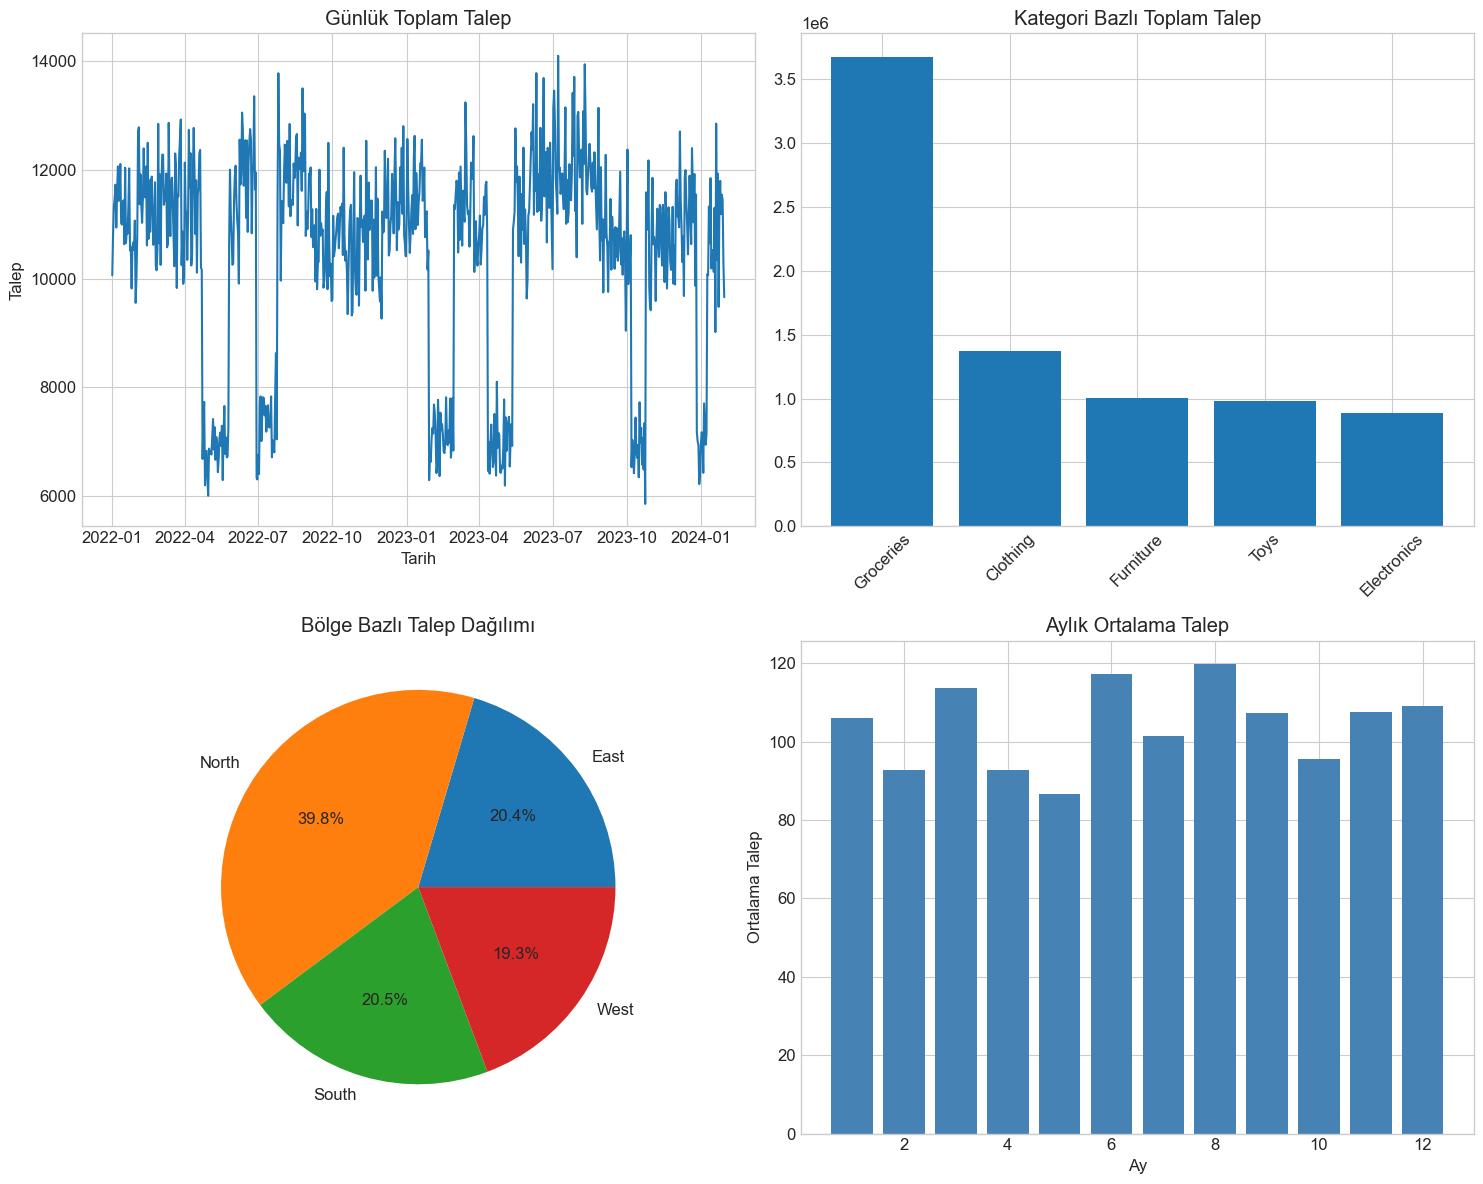

Görselleştirme kaydedildi: ../results/01_eda_visualizations.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

daily_demand = df.groupby('Date')['Demand'].sum()
axes[0, 0].plot(daily_demand.index, daily_demand.values)
axes[0, 0].set_title('Günlük Toplam Talep')
axes[0, 0].set_xlabel('Tarih')
axes[0, 0].set_ylabel('Talep')

category_demand = df.groupby('Category')['Demand'].sum().sort_values(ascending=False)
axes[0, 1].bar(category_demand.index, category_demand.values)
axes[0, 1].set_title('Kategori Bazlı Toplam Talep')
axes[0, 1].tick_params(axis='x', rotation=45)

region_demand = df.groupby('Region')['Demand'].sum()
axes[1, 0].pie(region_demand.values, labels=region_demand.index, autopct='%1.1f%%')
axes[1, 0].set_title('Bölge Bazlı Talep Dağılımı')

monthly_demand = df.groupby('Month')['Demand'].mean()
axes[1, 1].bar(monthly_demand.index, monthly_demand.values, color='steelblue')
axes[1, 1].set_title('Aylık Ortalama Talep')
axes[1, 1].set_xlabel('Ay')
axes[1, 1].set_ylabel('Ortalama Talep')

plt.tight_layout()
plt.savefig('../results/01_eda_visualizations.png', dpi=150)
plt.show()
print('Görselleştirme kaydedildi: ../results/01_eda_visualizations.png')

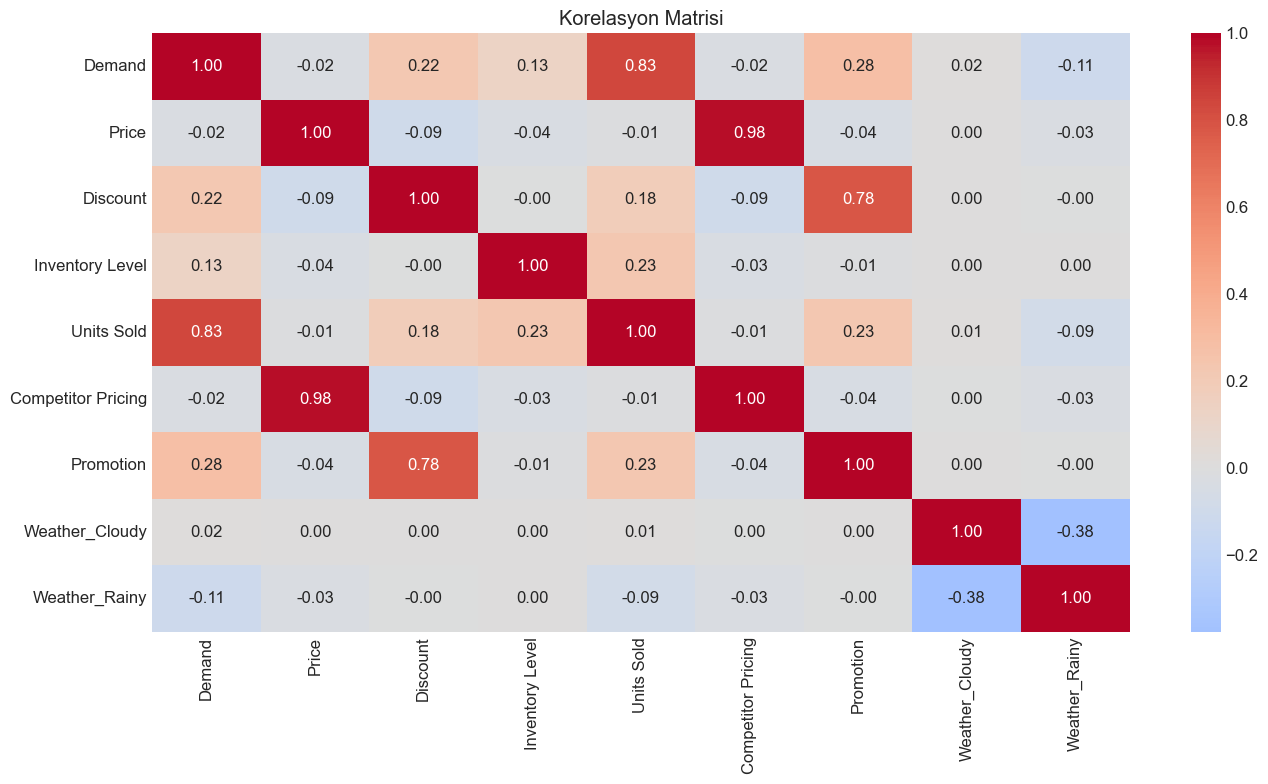

In [12]:
plt.figure(figsize=(14, 8))
corr_cols = ['Demand', 'Price', 'Discount', 'Inventory Level', 'Units Sold', 
             'Competitor Pricing', 'Promotion', 'Weather_Cloudy', 'Weather_Rainy']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('../results/02_correlation_matrix.png', dpi=150)
plt.show()

## 5. Model Eğitimi

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

feature_cols = [col for col in df.columns if col not in 
                ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 
                 'Weather Condition', 'Seasonality', 'Demand']]

X = df[feature_cols]
y = df['Demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Eğitim Seti: {X_train.shape}')
print(f'Test Seti: {X_test.shape}')

Eğitim Seti: (60800, 34)
Test Seti: (15200, 34)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=0.1, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=100, random_state=42, verbose=0),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5)
}

results = {}

for name, model in models.items():
    print(f'{name} eğitiliyor...')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'  RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}\n')

Ridge Regression eğitiliyor...
  RMSE: 21.15, MAE: 15.79, R2: 0.7975

ElasticNet eğitiliyor...
  RMSE: 21.20, MAE: 15.83, R2: 0.7965

Random Forest eğitiliyor...
  RMSE: 17.03, MAE: 12.81, R2: 0.8686

Gradient Boosting eğitiliyor...
  RMSE: 17.85, MAE: 13.77, R2: 0.8557

XGBoost eğitiliyor...
  RMSE: 16.24, MAE: 12.27, R2: 0.8806

LightGBM eğitiliyor...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,001815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2219
[LightGBM] [Info] Number of data points in the train set: 60800, number of used features: 34
[LightGBM] [Info] Start training from score 104,315526
  RMSE: 16.51, MAE: 12.64, R2: 0.8766

CatBoost eğitiliyor...
  RMSE: 16.35, MAE: 12.43, R2: 0.8789

KNeighbors eğitiliyor...
  RMSE: 26.00, MAE: 19.95, R2: 0.6940



In [18]:
results_df = pd.DataFrame(results).T
results_df.to_csv('../results/03_model_comparison.csv')
print('Model Karşılaştırma Sonuçları:')
print(results_df)

best_model_name = results_df['R2'].idxmax()
print(f'\nEn İyi Model: {best_model_name}')

Model Karşılaştırma Sonuçları:
                        RMSE        MAE        R2
Ridge Regression   21.145654  15.794083  0.797539
ElasticNet         21.201401  15.827415  0.796470
Random Forest      17.033668  12.805255  0.868624
Gradient Boosting  17.852998  13.765518  0.855682
XGBoost            16.239568  12.269996  0.880588
LightGBM           16.510974  12.644041  0.876563
CatBoost           16.354000  12.429606  0.878899
KNeighbors         25.998372  19.947882  0.693950

En İyi Model: XGBoost


## 6. Model Değerlendirme

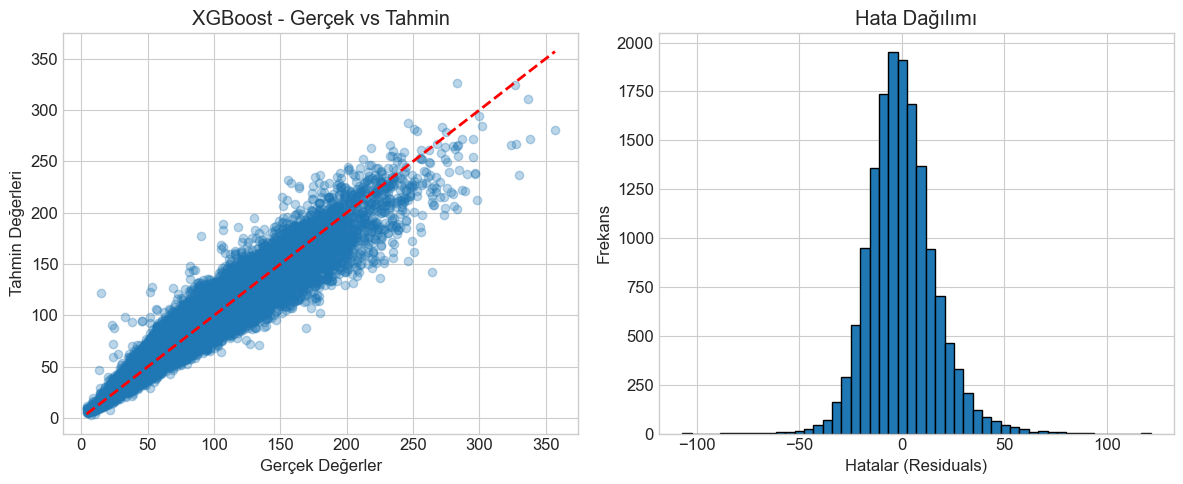

In [19]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_best, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gerçek Değerler')
plt.ylabel('Tahmin Değerleri')
plt.title(f'{best_model_name} - Gerçek vs Tahmin')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred_best
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Hatalar (Residuals)')
plt.ylabel('Frekans')
plt.title('Hata Dağılımı')

plt.tight_layout()
plt.savefig('../results/04_model_evaluation.png', dpi=150)
plt.show()

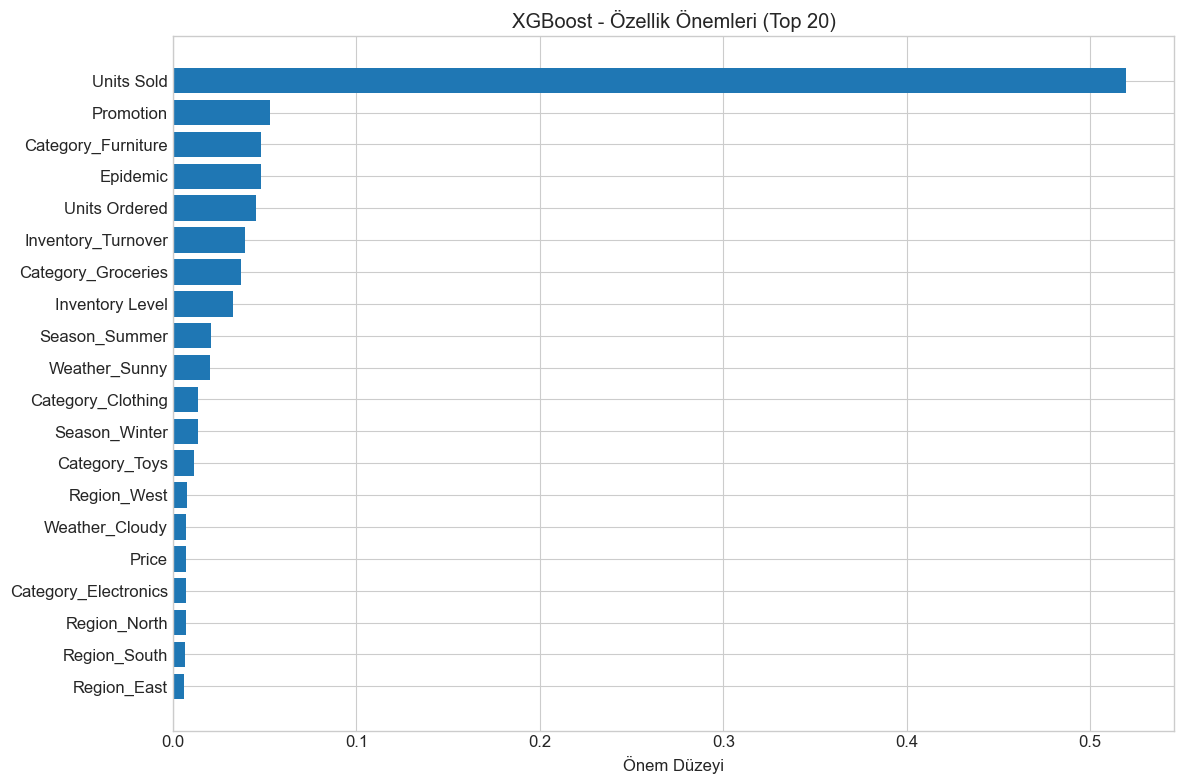


En Önemli 10 Özellik:
               feature  importance
1           Units Sold    0.519741
5            Promotion    0.053010
16  Category_Furniture    0.048023
7             Epidemic    0.047925
2        Units Ordered    0.045348
33  Inventory_Turnover    0.039367
17  Category_Groceries    0.037269
0      Inventory Level    0.032466
29       Season_Summer    0.020858
26       Weather_Sunny    0.020371


In [20]:
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    top_20 = feature_importance.head(20)
    plt.barh(top_20['feature'], top_20['importance'])
    plt.xlabel('Önem Düzeyi')
    plt.title(f'{best_model_name} - Özellik Önemleri (Top 20)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../results/05_feature_importance.png', dpi=150)
    plt.show()
    
    print('\nEn Önemli 10 Özellik:')
    print(feature_importance.head(10))

## 7. Sonuçlar ve Öneriler

In [21]:
print('='*60)
print('TALEP TAHMİNİ PROJESİ SONUÇLARI')
print('='*60)
print(f'\nVeri Seti: {df.shape[0]} satır, {df.shape[1]} sütun')
print(f'Tarih Aralığı: {df["Date"].min().date()} - {df["Date"].max().date()}')
print(f'Mağaza Sayısı: {df["Store ID"].nunique()}')
print(f'Ürün Sayısı: {df["Product ID"].nunique()}')
print(f'Kategori Sayısı: {df["Category"].nunique()}')
print(f'\nEn İyi Model: {best_model_name}')
print(f'R2 Skoru: {results[best_model_name]["R2"]:.4f}')
print(f'RMSE: {results[best_model_name]["RMSE"]:.2f}')
print(f'MAE: {results[best_model_name]["MAE"]:.2f}')
print('\n' + '='*60)

TALEP TAHMİNİ PROJESİ SONUÇLARI

Veri Seti: 76000 satır, 42 sütun
Tarih Aralığı: 2022-01-01 - 2024-01-30
Mağaza Sayısı: 5
Ürün Sayısı: 20
Kategori Sayısı: 5

En İyi Model: XGBoost
R2 Skoru: 0.8806
RMSE: 16.24
MAE: 12.27



In [22]:
import joblib

joblib.dump(best_model, '../models/best_demand_forecasting_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print('Model kaydedildi: ../models/best_demand_forecasting_model.pkl')
print('Scaler kaydedildi: ../models/scaler.pkl')

Model kaydedildi: ../models/best_demand_forecasting_model.pkl
Scaler kaydedildi: ../models/scaler.pkl
